**Задача 1.** Использование PCA и t-SNE для визуализации набора данных MNIST. Ниже пример использования PCA для целого набора данных и t-SNE для его небольшой части. От Вас требуется всего лишь повторить последний пример, но для большего набора данных.

In [8]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Загрузим набор MNIST. Поскольку мы собираемся использовать PCA для визуализации, оставим только две главные компоненты.

In [2]:
mnist = fetch_openml('mnist_784', cache=False)
mnist.data.shape

(70000, 784)

In [3]:
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')
X /= 255.0
X.min(), X.max()

(0.0, 1.0)

In [4]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X)

print("Новая размерность = ", pca_data.shape)
pca_data = np.vstack((pca_data.T, y)).T

Новая размерность =  (70000, 2)


Построим данные.

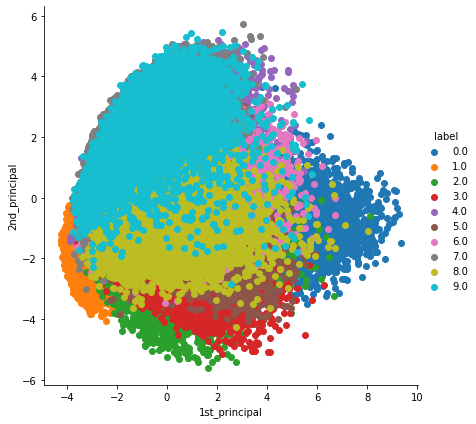

In [9]:
pca_df = pd.DataFrame(data=pca_data, columns=("1st_principal", "2nd_principal", "label"))
sn.FacetGrid(pca_df, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

Теперь используем t-SNE для этой же цели. Поскольку t-SNE очень вычислительно затратный метод, разобъем наш набор из 70000 изображений на наборы поменьше. Это можно сделать например с помощью двух вызовов функции train_test_split.

In [10]:
X1, Xtemp, y1, ytemp = train_test_split(X, y, test_size=0.25, random_state=42)
X2, X3, y2, y3 = train_test_split(Xtemp, ytemp, test_size=0.1, random_state=42)

In [11]:
X1.shape, X2.shape, X3.shape

((52500, 784), (15750, 784), (1750, 784))

Далее я возьму самый маленький набор, а Вы позже возьмите набор побольше, чтобы успеть выпить кофе.

In [12]:
data = X3
labels = y3

model = TSNE(n_components=2, random_state=0)
# configuring the parameteres
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations for the optimization = 1000

tsne_data = model.fit_transform(data)
tsne_data = np.vstack((tsne_data.T, labels)).T

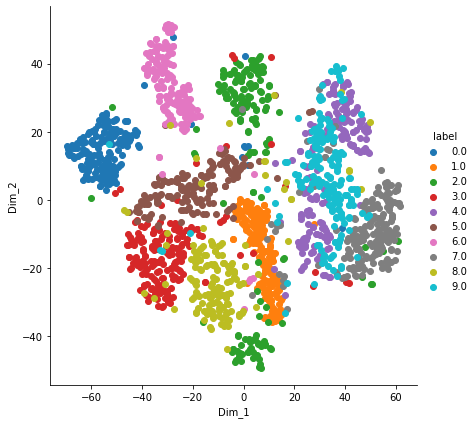

In [13]:
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.show()

Неплохо в сравнении с PCA даже для такого небольшого набора, а если взять больше точек, то результат того стоит.

**Задача 2.**
Определите номер варианта - найдите число букв в Вашей фамилии, поделите его на 4, возьмите остаток от деления и прибавьте 1.

Пример:

Иванов - 6 букв, 6%4+1=2+1=3.

Изучите встроенные в sklearn игрушечные датасеты.
https://scikit-learn.org/stable/datasets/index.html

    1) Boston house prices dataset

    2) Diabetes dataset

    3) Wine recognition dataset

    4) Breast cancer wisconsin (diagnostic) dataset

Для датасета, согласно своему варианту, сделайте следующее:

1) Загрузите его.

2) Используйте 3 любых изученных нами метода машинного обучения для решения задачи регрессии/классификации Ваших данных.

3) Используйте изученные методы (решетчатый поиск, перекрестную проверку) для поиска наилучших параметров Ваших моделей.